In [14]:
import os
import sys
from pathlib import Path
import polars as pl
import pandas as pd
import numpy as np
import gc
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix, classification_report, precision_recall_curve, balanced_accuracy_score, matthews_corrcoef, average_precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import ParameterSampler
import matplotlib.pyplot as plt

current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = False

# 1. Načtení dat

In [7]:
lf_prohlidky = pl.scan_parquet(r"E:\CVUT_BAP\kod\data\processed\mereni_model.parquet")
lf_mereni = pl.scan_parquet(r"E:\CVUT_BAP\kod\data\processed\prohlidky_model.parquet")
df = lf_prohlidky.join(lf_mereni, on='CisloProtokolu', how='inner').collect()#.sample(fraction=0.1, seed=SEED)

# 2. Definice proměnných

In [8]:
id_col = 'CisloProtokolu'
target_col = 'Vysledek_Pristi'

# Identifikace sloupců
all_cols = df.columns
feature_cols = [c for c in all_cols if c not in [id_col, target_col]]

# Automatická detekce kategorických a numerických sloupců
cat_features = [c for c in feature_cols if df[c].dtype in [pl.String, pl.Boolean]]
num_features = [c for c in feature_cols if df[c].dtype in [pl.Float32, pl.Float64, pl.Int32, pl.Int8, pl.UInt32]]

# 3. Typová optimalizace (Polars) pro minimalizaci 

In [9]:
df = df.with_columns([
    pl.col(c).cast(pl.Float32) for c in num_features
]).with_columns([
    pl.col(c).cast(pl.String).fill_null("missing") for c in cat_features
]).with_columns(
    # Inverze zajistí, že 1 = Neúspěch.
    (1 - pl.col(target_col)).cast(pl.Int8).alias(target_col)
)

# 4. Konverze do Pandas 

In [11]:
# ID sloupec je vyřazen z trénovacích dat
df_pd = df.select(feature_cols + [target_col]).to_pandas()

# Odstranění Polars DataFrame z paměti
del df
_ = gc.collect()

# 5. Rozdělení dat (Train 80 %, Val 10 %, Test 10 %) se stratifikací

In [12]:
X = df_pd[feature_cols]
y = df_pd[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=SEED, stratify=y_temp)

# Odstranění dočasných proměnných
del df_pd, X, y, X_temp, y_temp
_ = gc.collect()

# 6. Inicializace objektů Pool

In [13]:
# Převedení dat do interního formátu CatBoost zefektivní využití paměti na GPU
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_val, y_val, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

del X_train, y_train, X_val, y_val, X_test, y_test
_ = gc.collect()

# 7. Konfigurace a trénování modelu 

In [16]:
# Definice prostoru hyperparametrů
param_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

# Výběr 4 náhodných kombinací pro úsporu času na starším GPU
param_list = list(ParameterSampler(param_grid, n_iter=4, random_state=SEED))

best_score = float('inf')
best_params = None
best_model = None

print("--- Start Hyperparameter Tuningu ---")
for i, params in enumerate(param_list):
    print(f"\nModel {i+1}/{len(param_list)} | Parametry: {params}")
    
    current_model = CatBoostClassifier(
        iterations=10000,              # Extrémní limit, konvergenci řídí early_stopping
        task_type='GPU',         
        devices='0',             
        max_ctr_complexity=1,    
        eval_metric='Logloss',
        random_seed=SEED,
        early_stopping_rounds=20,
        auto_class_weights='Balanced',
        **params
    )
    
    current_model.fit(
        train_pool,
        eval_set=val_pool,
        verbose=50
    )
    
    # Vyhodnocení Logloss na validační sadě
    val_loss = current_model.get_best_score()['validation']['Logloss']
    print(f"Dosažený Logloss: {val_loss:.4f} v iteraci {current_model.get_best_iteration()}")
    
    if val_loss < best_score:
        best_score = val_loss
        best_params = params
        best_model = current_model

print(f"\n--- Konec Tuningu ---")
print(f"Nejlepší parametry: {best_params}")

# Model s nejlepšími parametry
model = best_model

--- Start Hyperparameter Tuningu ---

Model 1/4 | Parametry: {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'depth': 4}
0:	learn: 0.6823141	test: 0.6823083	best: 0.6823083 (0)	total: 255ms	remaining: 42m 28s
50:	learn: 0.6074500	test: 0.6076126	best: 0.6076126 (50)	total: 11.7s	remaining: 37m 54s
100:	learn: 0.6026352	test: 0.6032101	best: 0.6032101 (100)	total: 22.6s	remaining: 36m 58s
150:	learn: 0.6003589	test: 0.6012415	best: 0.6012415 (150)	total: 33.5s	remaining: 36m 23s
200:	learn: 0.5986215	test: 0.5998159	best: 0.5998159 (200)	total: 44.7s	remaining: 36m 17s
250:	learn: 0.5972372	test: 0.5985972	best: 0.5985972 (250)	total: 55.8s	remaining: 36m 5s
300:	learn: 0.5961655	test: 0.5978006	best: 0.5978006 (300)	total: 1m 7s	remaining: 35m 59s
350:	learn: 0.5953045	test: 0.5970887	best: 0.5970887 (350)	total: 1m 18s	remaining: 35m 47s
400:	learn: 0.5944139	test: 0.5963804	best: 0.5963804 (400)	total: 1m 28s	remaining: 35m 30s
450:	learn: 0.5936168	test: 0.5957322	best: 0.5957322 (450)	tot

# 8. Vyhodnocení na testovací sadě

Použitý práh: 0.5
Balanced Accuracy (Test): 0.6893

--- Klasifikační report na TESTOVACÍ sadě (1 = Neúspěch) ---
              precision    recall  f1-score   support

  Úspěch (0)       0.99      0.66      0.79    945129
Neúspěch (1)       0.05      0.72      0.10     25692

    accuracy                           0.66    970821
   macro avg       0.52      0.69      0.45    970821
weighted avg       0.96      0.66      0.77    970821



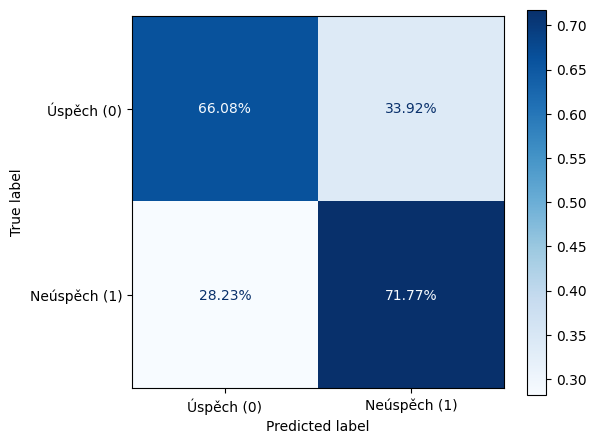

In [ ]:
# Aplikace fixního prahu a vyhodnocení na TESTOVACÍ SADĚ
optimal_threshold = 0.5
y_test_proba = model.predict_proba(test_pool)[:, 1]
y_test_labels = test_pool.get_label()
y_test_pred = (y_test_proba >= optimal_threshold).astype(int)

# Výpočet matic (absolutní i relativní)
cm_abs = confusion_matrix(y_test_labels, y_test_pred)
cm_rel = confusion_matrix(y_test_labels, y_test_pred, normalize='true')

# Výpis ukazatelů
print(f"Použitý práh: {optimal_threshold:.1f}")
print(f"Balanced Accuracy (Test): {balanced_accuracy_score(y_test_labels, y_test_pred):.4f}")
print("\n--- Klasifikační report na TESTOVACÍ sadě (1 = Neúspěch) ---")
print(classification_report(y_test_labels, y_test_pred, target_names=['Úspěch (0)', 'Neúspěch (1)']))

# Vizualizace relativní matice záměn
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rel, 
    display_labels=['Úspěch (0)', 'Neúspěch (1)']
)
_ = disp.plot(cmap='Blues', ax=ax, values_format='.2%')